In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
nav = pd.read_csv("/content/Cleaned_02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
print(nav.shape)
print(nav.columns)

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='object')


In [ ]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

In [ ]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [ ]:
import os

os.makedirs("/content/reports", exist_ok=True)

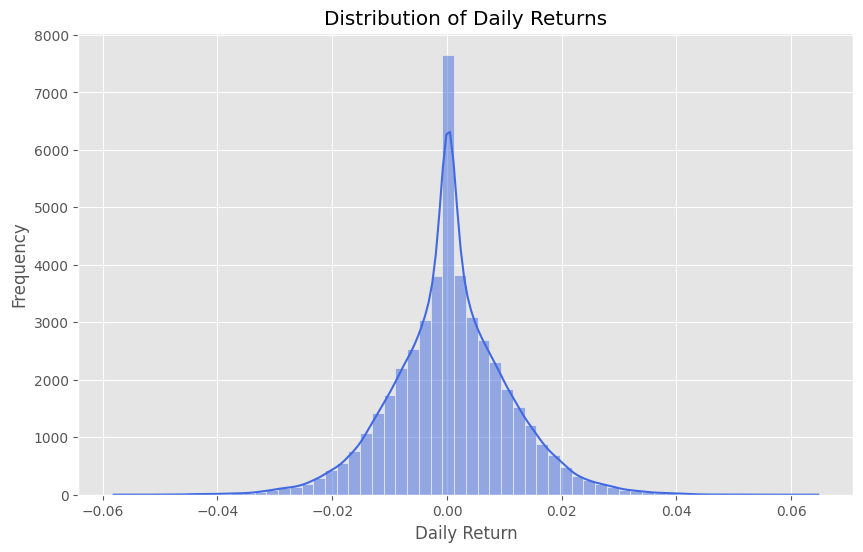

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"],
    bins=60,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.savefig(
    "/content/reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

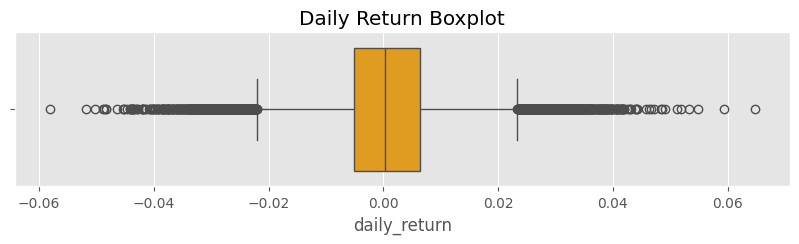

In [ ]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=nav["daily_return"],
    color="orange"
)

plt.title("Daily Return Boxplot")

plt.savefig(
    "/content/reports/daily_return_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd

# Read NAV history data
nav_history = pd.read_csv("/content/Cleaned_02_nav_history.csv")

# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [ ]:
# Sort data
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Function to calculate CAGR
def calculate_cagr(group, years):
    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    start_data = group[group["date"] >= start_date].head(1)
    end_data = group.tail(1)

    if start_data.empty or end_data.empty:
        return None

    start_nav = start_data["nav"].iloc[0]
    end_nav = end_data["nav"].iloc[0]

    return (end_nav / start_nav) ** (1 / years) - 1

# Comparison table
cagr_table = pd.DataFrame({
    "CAGR_1Y": nav_history.groupby("amfi_code").apply(lambda x: calculate_cagr(x, 1)),
    "CAGR_3Y": nav_history.groupby("amfi_code").apply(lambda x: calculate_cagr(x, 3)),
    "CAGR_5Y": nav_history.groupby("amfi_code").apply(lambda x: calculate_cagr(x, 5))
}).reset_index()

# Convert to percentage
cagr_table[["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]] *= 100

# Display comparison table
cagr_table

/tmp/ipykernel_3391/2397782668.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "CAGR_1Y": nav_history.groupby("amfi_code").apply(lambda x: calculate_cagr(x, 1)),
/tmp/ipykernel_3391/2397782668.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "CAGR_3Y": nav_history.groupby("amfi_code").apply(lambda x: calculate_cagr(x, 3)),
/tmp/ipykernel_3391/2397782668.py:24: DeprecationWarning: DataFrameGroupBy.a

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336
5,101208,7.236645,6.315784,5.705734
6,102885,20.207704,19.667262,15.878823
7,102886,-16.797481,-0.767406,1.030350
8,102887,13.583135,25.556188,14.678110
9,118632,33.981048,22.652360,20.881118


In [ ]:
import pandas as pd
import numpy as np

# Read NAV history data
nav_history = pd.read_csv("/content/Cleaned_02_nav_history.csv")

# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort data
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Check data
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
# Calculate daily returns
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove first null returns
nav_returns = nav_history.dropna(subset=["daily_return"])

nav_returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [ ]:
# Risk free rate
rf = 0.065

# Calculate Sharpe Ratio for each fund
sharpe_table = (
    nav_returns.groupby("amfi_code")
    .agg(
        avg_daily_return=("daily_return", "mean"),
        std_daily_return=("daily_return", "std")
    )
    .reset_index()
)

# Annualized Sharpe Ratio
sharpe_table["Sharpe_Ratio"] = (
    (sharpe_table["avg_daily_return"] * 252 - rf)
    /
    (sharpe_table["std_daily_return"] * np.sqrt(252))
)

sharpe_table

,amfi_code,avg_daily_return,std_daily_return,Sharpe_Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661
5,101208,0.000242,0.000319,-0.815567
6,102885,0.000674,0.008086,0.817099
7,102886,0.000110,0.011424,-0.205832
8,102887,0.000645,0.009927,0.619518
9,118632,0.000865,0.008913,1.081659


In [ ]:
# Rank funds by Sharpe Ratio
sharpe_ranking = (
    sharpe_table[["amfi_code", "Sharpe_Ratio"]]
    .sort_values("Sharpe_Ratio", ascending=False)
    .reset_index(drop=True)
)

# Add rank column
sharpe_ranking.insert(
    0,
    "Rank",
    range(1, len(sharpe_ranking) + 1)
)

sharpe_ranking

,Rank,amfi_code,Sharpe_Ratio
0,1,148567,1.448291
1,2,120843,1.306744
2,3,148569,1.234930
3,4,119551,1.208267
4,5,120505,1.180101
5,6,149323,1.132122
6,7,100033,1.093699
7,8,118632,1.081659
8,9,101206,1.027213
9,10,120504,1.026524


In [ ]:
returns = nav.dropna(
    subset=['daily_return']
)

returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [ ]:
rf_daily = 0.065 / 252

In [ ]:
def calculate_sortino(group):

    excess_return = group['daily_return'] - rf_daily

    downside_returns = excess_return[
        excess_return < 0
    ]

    downside_std = downside_returns.std()

    if downside_std == 0:
        return np.nan

    sortino = (
        excess_return.mean()
        /
        downside_std
    ) * np.sqrt(252)

    return sortino

In [ ]:
sortino_ratio = (
    returns
    .groupby('amfi_code')
    .apply(calculate_sortino)
    .reset_index()
)


sortino_ratio.columns = [
    'amfi_code',
    'sortino_ratio'
]


sortino_ratio.head()

/tmp/ipykernel_3391/4232367521.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_sortino)


,amfi_code,sortino_ratio
0,100016,-0.348196
1,100025,-0.915371
2,100033,1.823824
3,101206,1.785592
4,101207,0.274615


In [ ]:
import pandas as pd
import numpy as np

from scipy.stats import linregress

In [ ]:
returns.to_csv(
    "/content/daily_returns.csv",
    index=False
)

In [ ]:
returns = pd.read_csv(
    "/content/daily_returns.csv"
)

returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-04,515.0971,-0.010306
1,100016,2022-01-05,521.7239,0.012865
2,100016,2022-01-06,515.7880,-0.011377
3,100016,2022-01-07,515.1639,-0.001210
4,100016,2022-01-10,510.7136,-0.008639


In [ ]:
returns.shape

(45960, 4)

In [ ]:
benchmark = pd.read_csv(
    "/content/10_benchmark_indices.csv"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [ ]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [ ]:
benchmark = benchmark.sort_values(
    'date'
)

In [ ]:
nifty100 = benchmark[
    benchmark['index_name']=="NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [ ]:
nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value'] /
    nifty100['close_value'].shift(1)
) - 1

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [ ]:
returns['date'] = pd.to_datetime(returns['date'])
nifty100['date'] = pd.to_datetime(nifty100['date'])

In [ ]:
fund = returns[
    returns['amfi_code']==returns['amfi_code'].iloc[0]
].copy()

In [ ]:
merged = fund.merge(
    nifty100,
    on='date',
    how='inner'
)

merged.head()

,amfi_code,date,nav,daily_return,index_name,close_value,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,NIFTY100,17537.52,-0.013540
1,100016,2022-01-05,521.7239,0.012865,NIFTY100,17607.73,0.004003
2,100016,2022-01-06,515.7880,-0.011377,NIFTY100,17556.05,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,NIFTY100,17664.02,0.006150
4,100016,2022-01-10,510.7136,-0.008639,NIFTY100,17516.51,-0.008351


In [ ]:
result = linregress(
    merged['benchmark_return'],
    merged['daily_return']
)

beta = result.slope

alpha = result.intercept * 252


print("Beta:", beta)
print("Alpha:", alpha)

Beta: -0.05826843143880889
Alpha: 0.03747580763443287


In [ ]:
alpha_beta = []

for code in returns['amfi_code'].unique():

    fund = returns[
        returns['amfi_code']==code
    ].copy()

    merged = fund.merge(
        nifty100,
        on='date',
        how='inner'
    )

    if len(merged) > 30:

        result = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha_beta.append({
            "amfi_code": code,
            "alpha": result.intercept * 252,
            "beta": result.slope
        })


alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head(40)

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289
5,101208,0.060861,0.000267
6,102885,0.170488,-0.019487
7,102886,0.028969,-0.042125
8,102887,0.162113,0.016683
9,118632,0.218294,-0.008354


In [ ]:
alpha_beta_df.to_csv(
    "/content/alpha_beta_results.csv",
    index=False
)

In [ ]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "/content/Cleaned_02_nav_history.csv"
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code','date']
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
nav['running_max'] = (
    nav.groupby('amfi_code')['nav']
    .cummax()
)

nav.head()

,amfi_code,date,nav,running_max
0,100016,2022-01-03,520.4608,520.4608
1,100016,2022-01-04,515.0971,520.4608
2,100016,2022-01-05,521.7239,521.7239
3,100016,2022-01-06,515.7880,521.7239
4,100016,2022-01-07,515.1639,521.7239


In [ ]:
nav['drawdown'] = (
    nav['nav'] / nav['running_max']
) - 1


nav.head()

,amfi_code,date,nav,running_max,drawdown
0,100016,2022-01-03,520.4608,520.4608,0.000000
1,100016,2022-01-04,515.0971,520.4608,-0.010306
2,100016,2022-01-05,521.7239,521.7239,0.000000
3,100016,2022-01-06,515.7880,521.7239,-0.011377
4,100016,2022-01-07,515.1639,521.7239,-0.012574


In [ ]:
max_drawdown = (
    nav.groupby('amfi_code')['drawdown']
    .min()
    .reset_index()
)

max_drawdown.columns = [
    'amfi_code',
    'maximum_drawdown'
]


max_drawdown.head()

,amfi_code,maximum_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [ ]:
worst_dates = (
    nav.loc[
        nav.groupby('amfi_code')['drawdown'].idxmin()
    ]
    [['amfi_code','date','drawdown']]
)


worst_dates.columns = [
    'amfi_code',
    'worst_drawdown_date',
    'maximum_drawdown'
]


worst_dates.head()

,amfi_code,worst_drawdown_date,maximum_drawdown
183,100016,2022-09-15,-0.247344
1559,100025,2023-07-28,-0.043083
2393,100033,2022-05-12,-0.162172
3842,101206,2023-07-05,-0.112916
5735,101207,2026-05-11,-0.354469


In [ ]:
drawdown_period = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp = temp.sort_values('date')

    worst = temp.loc[
        temp['drawdown'].idxmin()
    ]

    before_worst = temp[
        temp['date'] <= worst['date']
    ]

    peak = before_worst.loc[
        before_worst['nav'].idxmax()
    ]

    drawdown_period.append([
        fund,
        peak['date'],
        worst['date'],
        worst['drawdown']
    ])


drawdown_period = pd.DataFrame(
    drawdown_period,
    columns=[
        'amfi_code',
        'drawdown_start_date',
        'worst_drawdown_date',
        'maximum_drawdown'
    ]
)

drawdown_period.head()

,amfi_code,drawdown_start_date,worst_drawdown_date,maximum_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [ ]:
maximum_drawdown_report = drawdown_period.sort_values(
    'maximum_drawdown'
)

maximum_drawdown_report.head(10)

,amfi_code,drawdown_start_date,worst_drawdown_date,maximum_drawdown
22,119599,2023-01-17,2025-10-28,-0.525742
17,119095,2025-05-22,2026-05-11,-0.516778
4,101207,2024-11-21,2026-05-11,-0.354469
39,149324,2024-05-03,2025-01-03,-0.311719
21,119598,2024-08-28,2025-05-14,-0.287060
7,102886,2025-01-07,2026-04-27,-0.280011
0,100016,2022-03-30,2022-09-15,-0.247344
29,120842,2023-11-09,2024-10-17,-0.240035
11,118634,2025-04-09,2026-02-20,-0.233449
15,119093,2022-02-24,2023-05-22,-0.217514


In [ ]:
maximum_drawdown_report['maximum_drawdown_pct'] = (
    maximum_drawdown_report['maximum_drawdown'] * 100
)


maximum_drawdown_report.head()

,amfi_code,drawdown_start_date,worst_drawdown_date,maximum_drawdown,maximum_drawdown_pct
22,119599,2023-01-17,2025-10-28,-0.525742,-52.574221
17,119095,2025-05-22,2026-05-11,-0.516778,-51.677754
4,101207,2024-11-21,2026-05-11,-0.354469,-35.446916
39,149324,2024-05-03,2025-01-03,-0.311719,-31.171900
21,119598,2024-08-28,2025-05-14,-0.287060,-28.706006


In [ ]:
maximum_drawdown_report.to_csv(
    "/content/maximum_drawdown_report.csv",
    index=False
)

In [ ]:
import pandas as pd

performance = pd.read_csv(
    "/content/07_scheme_performance.csv"
)

fund_master = pd.read_csv(
    "/content/Cleaned_01_data_fund_master.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [ ]:
performance.columns


Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [ ]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [ ]:
scorecard = performance.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name_x,fund_house_x,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct_x,morningstar_rating,risk_grade,scheme_name_y,fund_house_y,expense_ratio_pct_y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.70,14288,1.54,4,Moderate,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1.29,14.0,-24.43,1231,0.66,3,Moderate,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.35,25.0,-13.35,19259,1.43,5,Very High,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,1.67,25.0,-24.78,36061,0.72,4,Very High,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,2.11,4.0,-2.30,24101,0.77,5,Low,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,0.77


In [ ]:
scorecard = scorecard.rename(
    columns={
        "scheme_name_x":"scheme_name",
        "fund_house_x":"fund_house",
        "expense_ratio_pct_x":"expense_ratio_pct"
    }
)


scorecard = scorecard.drop(
    columns=[
        "scheme_name_y",
        "fund_house_y",
        "expense_ratio_pct_y"
    ]
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [ ]:
scorecard[
    [
        "return_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown_pct"
    ]
].head()

,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct
0,12.36,0.88,0.87,1.54,-21.70
1,11.30,0.81,1.78,0.66,-24.43
2,23.39,0.94,1.23,1.43,-13.35
3,23.14,0.93,1.13,0.72,-24.78
4,6.07,1.52,1.60,0.77,-2.30


In [ ]:
total_funds = len(scorecard)


scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)


scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)


scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)


scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)


scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(
    ascending=True
)

In [ ]:
scorecard["return_score"] = (
    (total_funds - scorecard["return_rank"] + 1)
    / total_funds
) * 100


scorecard["sharpe_score"] = (
    (total_funds - scorecard["sharpe_rank"] + 1)
    / total_funds
) * 100


scorecard["alpha_score"] = (
    (total_funds - scorecard["alpha_rank"] + 1)
    / total_funds
) * 100


scorecard["expense_score"] = (
    (total_funds - scorecard["expense_rank"] + 1)
    / total_funds
) * 100


scorecard["drawdown_score"] = (
    (total_funds - scorecard["drawdown_rank"] + 1)
    / total_funds
) * 100

In [ ]:
scorecard["fund_score"] = (
    0.30 * scorecard["return_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

In [ ]:
final_scorecard = scorecard[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "return_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown_pct",
        "fund_score"
    ]
].sort_values(
    by="fund_score",
    ascending=False
)

final_scorecard.head(10)

,amfi_code,scheme_name,fund_house,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14,0.93,1.13,0.72,-24.78,72.7500
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,15.65,0.98,1.85,1.45,-19.50,71.5000
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,18.23,0.96,1.91,1.56,-21.92,70.5000
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,22.38,0.90,1.84,1.53,-23.61,68.2500
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,0.94,1.23,1.43,-13.35,64.3750
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,14.81,1.06,1.62,1.46,-17.07,63.9375
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,7.37,1.84,1.98,0.56,-6.01,63.0000
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68,7.68,1.85,0.74,-2.62,61.7500
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,18.08,0.95,0.89,1.36,-21.84,61.0000
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,14.41,1.03,0.88,0.80,-26.59,59.6250


In [ ]:
final_scorecard.to_csv(
    "/content/fund_scorecard.csv",
    index=False
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NAV data
nav = pd.read_csv(
    "/content/Cleaned_02_nav_history.csv"
)

# Benchmark data
benchmark = pd.read_csv(
    "/content/10_benchmark_indices.csv"
)

nav.head(), benchmark.head()

(   amfi_code        date       nav
 0     100016  2022-01-03  520.4608
 1     100016  2022-01-04  515.0971
 2     100016  2022-01-05  521.7239
 3     100016  2022-01-06  515.7880
 4     100016  2022-01-07  515.1639,
          date index_name  close_value
 0  2022-01-03    NIFTY50     17492.79
 1  2022-01-04    NIFTY50     17689.64
 2  2022-01-05    NIFTY50     17835.05
 3  2022-01-06    NIFTY50     17878.51
 4  2022-01-07    NIFTY50     17759.15)

In [ ]:
nav['date'] = pd.to_datetime(nav['date'])

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [ ]:
performance = pd.read_csv(
    "/content/07_scheme_performance.csv"
)

top5 = performance.sort_values(
    by="return_3yr_pct",
    ascending=False
).head(5)


top5[['amfi_code','scheme_name','return_3yr_pct']]

,amfi_code,scheme_name,return_3yr_pct
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14
29,101207,ABSL Small Cap Fund - Regular - Growth,22.38
27,119095,Axis Small Cap Fund - Regular - Growth,20.98
17,118634,Nippon India Small Cap Fund - Regular - Growth,20.15


In [ ]:
end_date = nav['date'].max()

start_date = end_date - pd.DateOffset(years=3)


nav_3yr = nav[
    (nav['date']>=start_date) &
    (nav['date']<=end_date)
]


nav_3yr.shape

(31400, 3)

In [ ]:
fund_returns = {}

for fund in top5['amfi_code']:

    temp = nav_3yr[
        nav_3yr['amfi_code']==fund
    ].copy()

    temp = temp.sort_values('date')

    temp['return'] = (
        temp['nav'] /
        temp['nav'].shift(1)
    ) - 1

    fund_returns[fund] = temp

In [ ]:
benchmark_3yr = benchmark[
    (benchmark['date']>=start_date) &
    (benchmark['date']<=end_date)
]


benchmark_3yr.head()

,date,index_name,close_value
365,2023-05-29,NIFTY50,24688.69
366,2023-05-30,NIFTY50,24558.17
367,2023-05-31,NIFTY50,24476.07
368,2023-06-01,NIFTY50,24375.89
369,2023-06-02,NIFTY50,24398.93


In [95]:
nifty50 = benchmark_3yr[
    benchmark_3yr['index_name']=="NIFTY50"
].copy()


nifty100 = benchmark_3yr[
    benchmark_3yr['index_name']=="NIFTY100"
].copy()


nifty50['return'] = (
    nifty50['close_value'] /
    nifty50['close_value'].shift(1)
)-1


nifty100['return'] = (
    nifty100['close_value'] /
    nifty100['close_value'].shift(1)
)-1

In [96]:
tracking_error = []


for fund in top5['amfi_code']:

    temp = fund_returns[fund]

    merged = temp.merge(
        nifty100[['date','return']],
        on='date',
        suffixes=('_fund','_benchmark')
    )


    error = (
        np.std(
            merged['return_fund'] -
            merged['return_benchmark']
        )
        *
        np.sqrt(252)
    )


    tracking_error.append(
        [
            fund,
            error
        ]
    )


tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)


tracking_error_df

,amfi_code,tracking_error
0,119598,0.286506
1,119599,0.271925
2,101207,0.292911
3,119095,0.283336
4,118634,0.275136


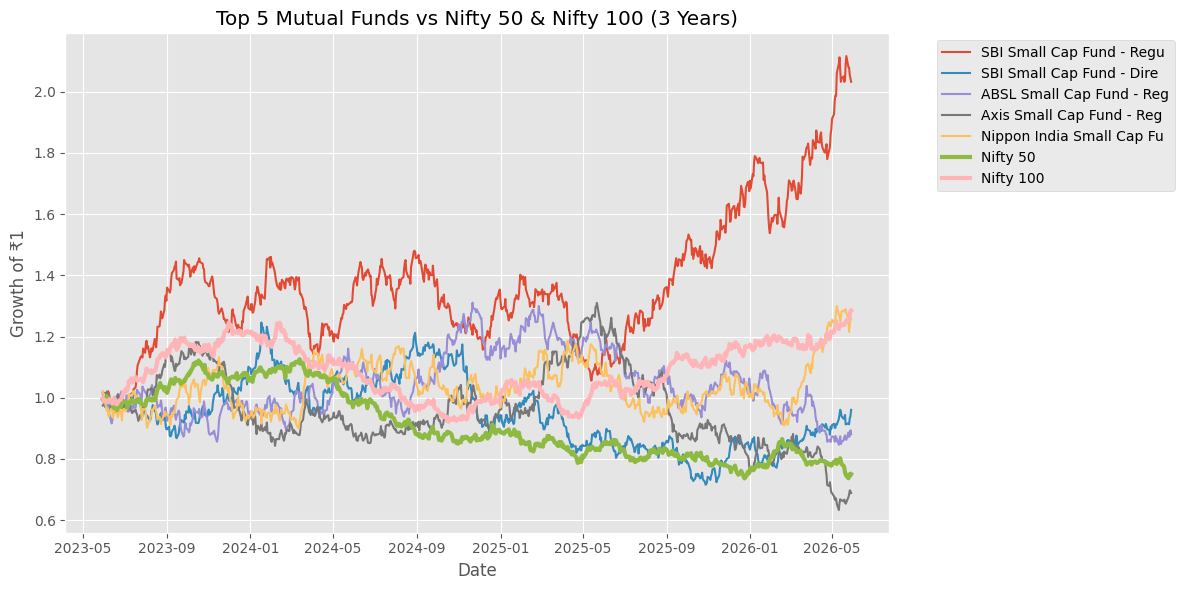

In [97]:
plt.figure(figsize=(12,6))


for fund in top5['amfi_code']:

    temp = fund_returns[fund]

    temp['growth'] = (
        1 + temp['return']
    ).cumprod()


    name = top5[
        top5['amfi_code']==fund
    ]['scheme_name'].values[0]


    plt.plot(
        temp['date'],
        temp['growth'],
        label=name[:25]
    )


# Nifty 50

nifty50['growth'] = (
    1+nifty50['return']
).cumprod()


plt.plot(
    nifty50['date'],
    nifty50['growth'],
    label="Nifty 50",
    linewidth=3
)



# Nifty 100

nifty100['growth'] = (
    1+nifty100['return']
).cumprod()


plt.plot(
    nifty100['date'],
    nifty100['growth'],
    label="Nifty 100",
    linewidth=3
)



plt.title(
    "Top 5 Mutual Funds vs Nifty 50 & Nifty 100 (3 Years)"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹1")


plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()


plt.savefig(
    "/content/reports/benchmark_comparison_top5.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [98]:
tracking_error_df.to_csv(
    "/content/tracking_error_top5.csv",
    index=False
)